# Inverse-distance embedding (fiducial) — cross-correlations (z = 0)

Companion to `inverse_distance_embedding_z0.ipynb`, for the **`corrfunc`
kernel** (the only env with `pycorr`/Corrfunc; it lacks `illustris_python`, so
this notebook loads positions and neighbour data from the compact NPZ).

Pipeline: load `snapshot99_embedding_r2_all_faster.npz` -> capped
inverse-distance profiles min(1/d, 10), sorted so each galaxy's nearest
neighbour occupies the last column -> embedding via numpy SVD of the centred
profile matrix (= the fiducial squared kernel / PCA; identical to the demo
notebook) -> two-point cross-correlations of embedding-selected subpopulations
against all galaxies with `pycorr` (periodic box -> analytic randoms; 3x3x3
jackknife errors), following the conventions of `cross_correlations.ipynb`.

Selections are computed **excluding the zero-neighbour galaxies** (identical
all-zero profiles that collapse to one degenerate embedding point at the
coordinate minimum), per the project rule; the reference sample keeps all
galaxies (positions are valid regardless of neighbour count).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pycorr import TwoPointCorrelationFunction, BoxSubsampler

BOXSIZE = 75.0                           # TNG100, comoving Mpc/h

## Load neighbour data and build the fiducial embedding

`sorted_neighbors` in the `_faster` file is N x K right-aligned ascending
distances (K = 376). The fiducial profile transforms each neighbour to
min(1/d, cap=10) and re-sorts, which pins the NEAREST neighbour to the last
column (0 = 1/infinity for absent neighbours). The embedding is the SVD of the
centred profile matrix — coordinate-identical to the `--kernel squared`
default of `generate_embedding_invdist.py` and to `PCA(10)` in the demo
notebook.

In [2]:
d = np.load('snapshot99_embedding_r2_all_faster.npz')
positions = d['positions']               # (N, 3) Mpc/h
sn = d['sorted_neighbors']
N = sn.shape[0]

CAP = 10.0
n_nbr = (sn > 0).sum(axis=1)
good = n_nbr > 0
print(f'N = {N}; zero-neighbour = {int((~good).sum())} [expected 1138]; '
      f'max n_nbr = {n_nbr.max()} [expected 376]')

with np.errstate(divide='ignore'):
    W = np.where(sn > 0, np.minimum(1.0 / sn, CAP), 0.0)
P = np.sort(W, axis=1)                   # nearest neighbour -> last column

Pc = P - P.mean(axis=0)
U, S, Vt = np.linalg.svd(Pc, full_matrices=False)
X = U[:, :10] * S[:10]                   # galaxy coordinates (= PCA scores)
var_share = np.cumsum(S**2) / np.sum(S**2)
print('cumulative variance share:', np.round(var_share[:3], 3),
      '[expected 0.718 / 0.866 / 0.927]')

# Sign convention: orient Dim 1 so HIGHER = denser (positive corr with count),
# so the top/bottom-20% labels below are unambiguous.
if np.corrcoef(X[good, 0], n_nbr[good])[0, 1] < 0:
    X[:, 0] *= -1
print(f'corr(Dim 1, n_nbr) = {np.corrcoef(X[good, 0], n_nbr[good])[0, 1]:+.3f}  '
      f'(oriented: high Dim 1 = dense)')

N = 27691; zero-neighbour = 1138 [expected 1138]; max n_nbr = 376 [expected 376]
cumulative variance share: [0.718 0.866 0.927] [expected 0.718 / 0.866 / 0.927]
corr(Dim 1, n_nbr) = +0.733  (oriented: high Dim 1 = dense)


## Cross-correlation machinery

Ported from `cross_correlations.ipynb` (post-fix version): periodic BCs via
`boxsize` (analytic randoms — do **not** pass random catalogs), positions
wrapped into [0, boxsize), 3x3x3 jackknife regions (25 Mpc/h > s_max = 20) for
error bands; only the diagonal of the jackknife covariance is used.

In [3]:
def plot_cross_corr(mask, positions=positions, boxsize=BOXSIZE, edges=None,
                    los='z', nthreads=4, ax=None, label=None,
                    plot_s_squared=False, color=None, linestyle='-'):
    """Cross-correlate positions[mask] (sample 2) against ALL positions
    (sample 1) and plot xi(s) or s^2 xi(s). An all-True mask gives the
    autocorrelation. Returns (s, xi)."""
    LABEL_FS, TICK_FS, LEGEND_FS = 22, 18, 14
    if edges is None:
        edges = np.logspace(np.log10(0.005), np.log10(20.0), 25)

    pos_all = positions % boxsize
    pos_sub = positions[mask] % boxsize

    subsampler = BoxSubsampler(boxsize=boxsize, boxcenter=boxsize / 2,
                               nsamples=(3, 3, 3), position_type='pos')
    labels_all = subsampler.label(pos_all)
    labels_sub = subsampler.label(pos_sub)

    result = TwoPointCorrelationFunction(
        's', edges,
        data_positions1=pos_all, data_positions2=pos_sub,
        data_samples1=labels_all, data_samples2=labels_sub,
        position_type='pos', los=los, boxsize=boxsize, nthreads=nthreads)

    s, xi = result.sep, result.corr
    err = np.sqrt(np.diag(result.cov()))          # jackknife 1-sigma

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xscale('log')
    y, yerr = (s**2 * xi, s**2 * err) if plot_s_squared else (xi, err)
    ax.plot(s, y, marker='o', markersize=4, color=color, linestyle=linestyle, label=label)
    ax.fill_between(s, y - yerr, y + yerr, alpha=0.3, color=color)
    ax.set_ylabel(r'$s^2 \xi(s)$' if plot_s_squared else r'$\xi(s)$',
                  fontsize=LABEL_FS)
    ax.axhline(0, ls=':', color='gray')
    ax.set_xlabel('s (Mpc/h)', fontsize=LABEL_FS)
    ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
    ax.tick_params(axis='both', which='minor', labelsize=TICK_FS - 4)
    if label is not None:
        ax.legend(fontsize=LEGEND_FS)
    return s, xi

## Clustering of embedding-selected subpopulations

For each of Dims 1-3: the bottom and top 20% (thresholds and masks computed on
galaxies with >= 1 neighbour), against the all-galaxy autocorrelation. With the
sign convention above, **top 20% of Dim 1 = densest environments**, so its
clustering should be strongest — the direct physical validation that the count
embedding orders environments correctly. The printed percentile locates the
degenerate point within each dimension (it is excluded from selections either
way). Runtime: 9 Corrfunc runs, a few minutes.

Dim 1: degenerate point sits at percentile ~0 of the good sample
Dim 2: degenerate point sits at percentile ~88 of the good sample
Dim 3: degenerate point sits at percentile ~25 of the good sample


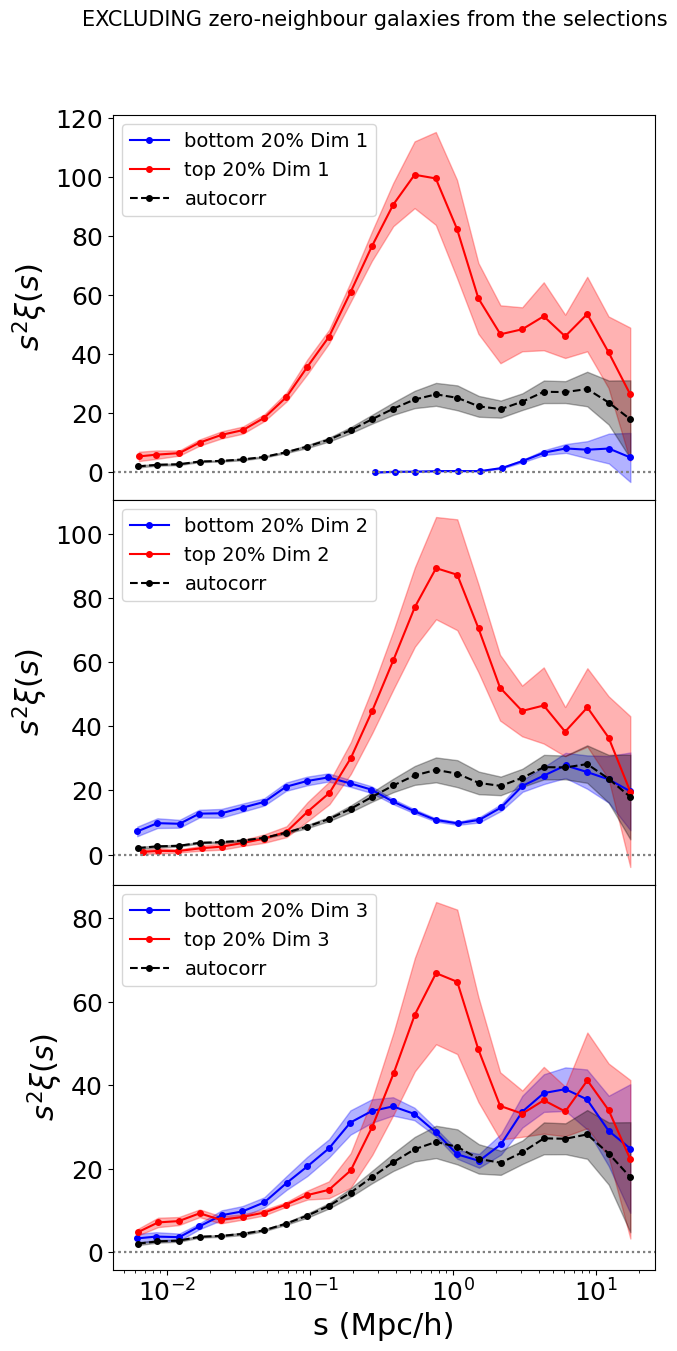

In [6]:
for k in range(3):
    pct = (X[good, k] < np.median(X[~good, k])).mean() * 100
    print(f'Dim {k+1}: degenerate point sits at percentile ~{pct:.0f} of the good sample')

fig, axes = plt.subplots(3, 1, figsize=(7, 15), sharex=True,
                         gridspec_kw={'hspace': 0})
all_mask = np.ones(N, dtype=bool)
for k, ax in enumerate(axes):
    dim = X[:, k]
    lo = np.percentile(dim[good], 20)
    hi = np.percentile(dim[good], 80)
    plot_cross_corr((dim <= lo) & good, ax=ax,
                    label=f'bottom 20% Dim {k+1}', plot_s_squared=True, color='blue')
    plot_cross_corr((dim >= hi) & good, ax=ax,
                    label=f'top 20% Dim {k+1}', plot_s_squared=True, color='red')
    plot_cross_corr(all_mask, ax=ax, label='autocorr', plot_s_squared=True,
                    color='black', linestyle='--')
    if k != len(axes) - 1:
        ax.set_xlabel('')
fig.suptitle('EXCLUDING zero-neighbour galaxies from the selections',
             fontsize=15, y=0.95)
plt.show()

## Same figure, INCLUDING the zero-neighbour galaxies

Percentile thresholds and selection masks computed over **all** galaxies, so
the 1,138-galaxy degenerate block participates. Where it lands (measured
above): Dim 1 percentile ~0 -- the entire block enters the *bottom-20% Dim 1*
selection (defensible: they are genuinely the most isolated galaxies); Dim 2
percentile ~88 -- the block is swallowed by the *top-20% Dim 2* selection;
Dim 3 percentile ~25 -- near the bottom-20% boundary, so its membership there
is threshold-sensitive. Comparing panels between the two figures shows how
much of each selection's clustering signal is contributed by the degenerate
class. The reference sample (all positions) is identical in both.

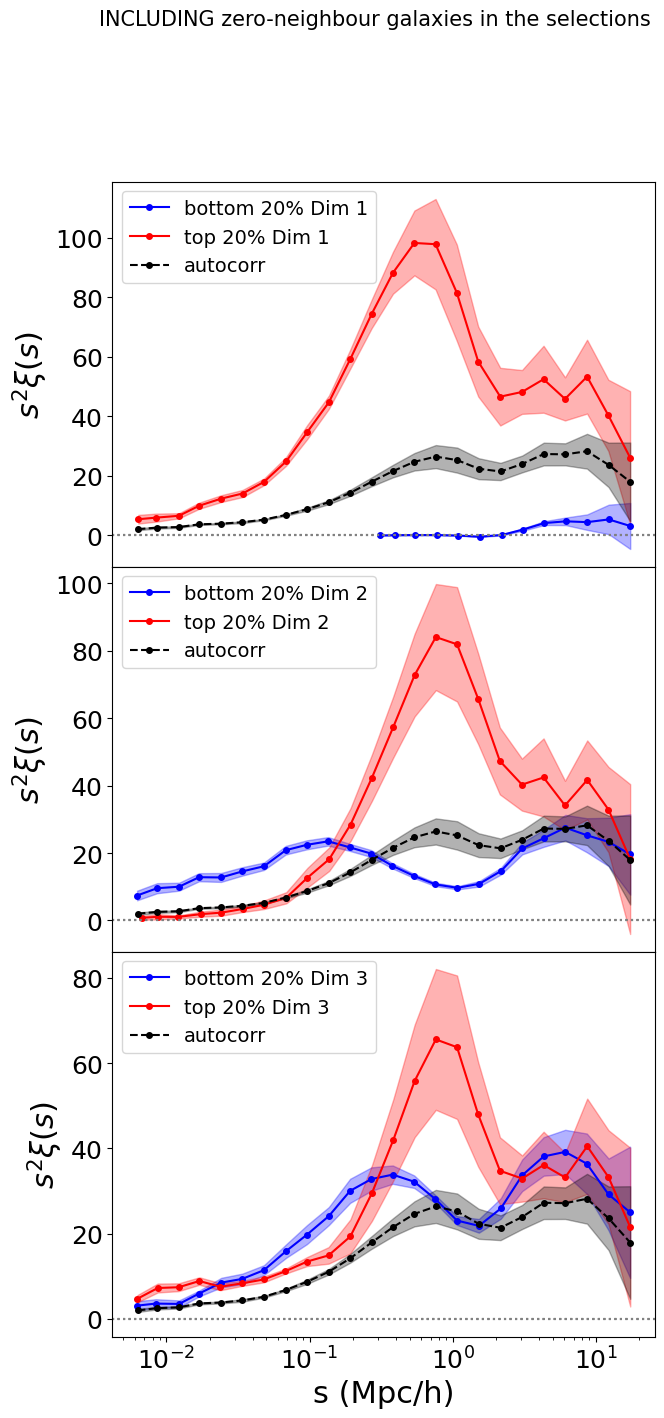

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(7, 15), sharex=True,
                         gridspec_kw={'hspace': 0})
for k, ax in enumerate(axes):
    dim = X[:, k]
    lo = np.percentile(dim, 20)          # thresholds over ALL galaxies
    hi = np.percentile(dim, 80)
    plot_cross_corr(dim <= lo, ax=ax,
                    label=f'bottom 20% Dim {k+1}', plot_s_squared=True, color='blue')
    plot_cross_corr(dim >= hi, ax=ax,
                    label=f'top 20% Dim {k+1}', plot_s_squared=True, color='red')
    plot_cross_corr(np.ones(N, dtype=bool), ax=ax, label='autocorr',
                    plot_s_squared=True, color='black', linestyle='--')
    if k != len(axes) - 1:
        ax.set_xlabel('')
fig.suptitle('INCLUDING zero-neighbour galaxies in the selections',
             fontsize=15, y=0.995)
plt.show()

## Notes

- With the density orientation of Dim 1, the red (top 20%) curve in the first
  panel should sit well above the autocorrelation and the blue curve below it.
- The jackknife caveats of `cross_correlations.ipynb` apply: 27 regions of
  25 Mpc/h support error bars to s ~ 20 Mpc/h but not an invertible covariance.
- For the old sorted-distance embedding's version of this figure see
  `figures/cross_correlations_excl0.pdf`; the count-representation companion
  of this notebook was its previous incarnation (`git` history / CLAUDE.md).

Dim 1: degenerate point sits at percentile ~0 of the good sample
Dim 2: degenerate point sits at percentile ~88 of the good sample
Dim 3: degenerate point sits at percentile ~25 of the good sample


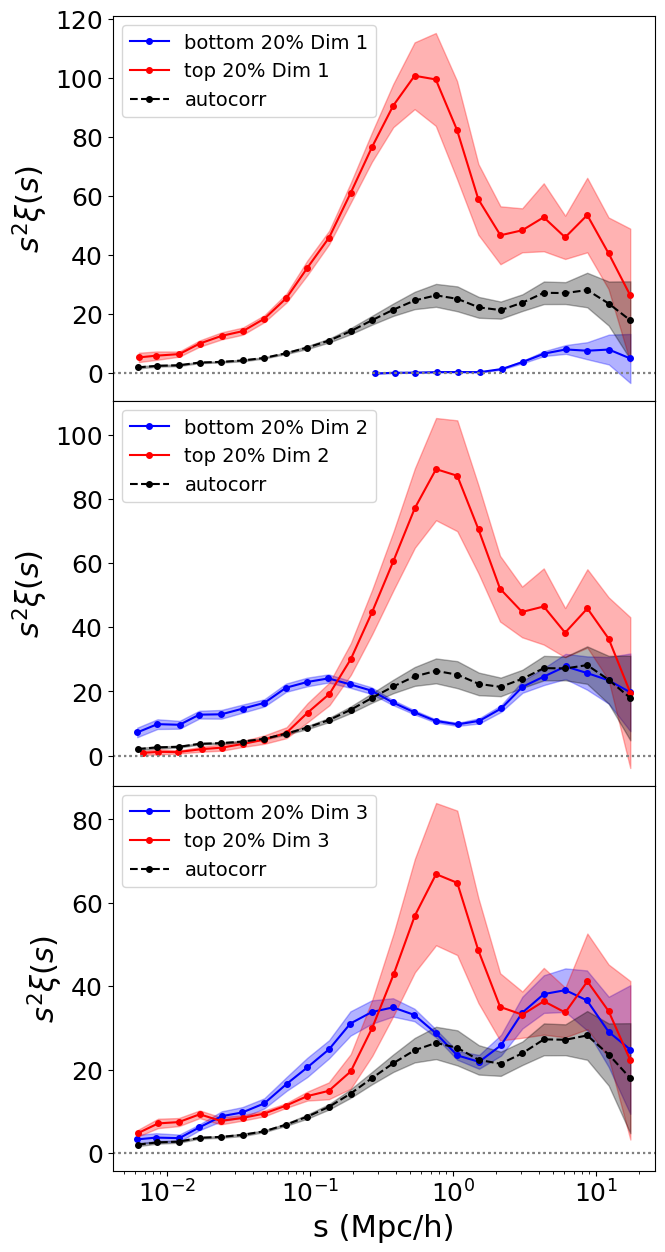

In [7]:
for k in range(3):
    pct = (X[good, k] < np.median(X[~good, k])).mean() * 100
    print(f'Dim {k+1}: degenerate point sits at percentile ~{pct:.0f} of the good sample')

fig, axes = plt.subplots(3, 1, figsize=(7, 15), sharex=True,
                         gridspec_kw={'hspace': 0})
all_mask = np.ones(N, dtype=bool)
for k, ax in enumerate(axes):
    dim = X[:, k]
    lo = np.percentile(dim[good], 20)
    hi = np.percentile(dim[good], 80)
    plot_cross_corr((dim <= lo) & good, ax=ax,
                    label=f'bottom 20% Dim {k+1}', plot_s_squared=True, color='blue')
    plot_cross_corr((dim >= hi) & good, ax=ax,
                    label=f'top 20% Dim {k+1}', plot_s_squared=True, color='red')
    plot_cross_corr(all_mask, ax=ax, label='autocorr', plot_s_squared=True,
                    color='black', linestyle='--')
    if k != len(axes) - 1:
        ax.set_xlabel('')
# fig.suptitle('EXCLUDING zero-neighbour galaxies from the selections',
#              fontsize=15, y=0.95)
plt.show()

In [8]:
fig.savefig('new_figures/invdist_cross_corrs.pdf', bbox_inches='tight')